In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from COMPAS.compas_python_utils.detailed_evolution_plotter import plot_detailed_evolution as det_evo
import tempfile

import h5py as h5 
from astropy import units as u
from astropy import constants as c

import os
import scipy

pd.options.display.max_columns = None

In [2]:
import matplotlib.pyplot as plt
from matplotlib import rcParams
import matplotlib
from matplotlib.ticker import LogLocator, AutoMinorLocator, MultipleLocator
# rcParams['font.family'] = 'serif'
# rcParams["mathtext.fontset"] = 'stix'
# rcParams["font.size"] = 18
fontparams = {
    "font.family": "serif",
    "mathtext.fontset" : "stix",
    "grid.color": "gray",
    "grid.linestyle": ":",
    "axes.titlesize": "18",
    "axes.labelsize": "12",
    "xtick.labelsize": "10",
    "ytick.labelsize": "10",
    "xtick.labelbottom": "True",
    "legend.framealpha": "1",
}
rcParams.update(fontparams) 

%config InlineBackend.figure_format='retina' # very useful command for high-res images


In [3]:
from cycler import cycler

colorPalette = {'red': "#E64D4E",
                'orange': "#EE9063",
                'yellow': "#FFDD7B",
                'green': "#77AC54",
                'blue': "#0B92B1",
                'violet': "#665191",
                'gray': "#B4B4B4"
}

custom_cycler = (cycler(color=[colorPalette['red'], colorPalette['blue'], colorPalette['green']]))
color_list = [colorPalette['red'], colorPalette['blue'], colorPalette['green']]

st_labels = ['MS_LT_0.7', 'MS_GT_0.7', 'HG', 'FGB', 'CHeB', 'EAGB', 'TPAGB', 'HeMS', 'HeHG', 'HeGB', 'HeWD', 'COWD', 'ONeWD', 'NS', 'BH', 'MR','CHE',  '--', '--', 'None']


In [24]:
columns_to_keep = ['Time', 'Mass(1)', 'Mass(2)', 'Radius(1)', 'Radius(2)', 'SemiMajorAxis', 'Eccentricity', 'Stellar_Type(1)', 'Stellar_Type(2)', 'Period(1)', 'Period(2)', 'Period_Orb', 'dmMT(1)', 'dmMT(2)', 'Omega(1)', 'Omega(2)', 'Omega_Orb', 'Record_Type']
columns_to_keep_sanity = ['Time', 'M1', 'M2', 'R1', 'R2', 'SemiMajorAxis_Rsun', 'ecc', 'StellarType_1', 'StellarType_2', 'Period1', 'Period2', 'Period_orb', 'J1_after', 'J2_after', 'Jorb_after', 'dM1_MT', 'dM2_MT', 
                          'ImK22_1', 'ImK22_2', 'ImK22_1_dyn', 'ImK22_2_dyn', 'ImK22_1_eq', 'ImK22_2_eq', 
                          'ImK22_Zahn_Equilibrium1', 'ImK22_Zahn_Equilibrium2', 'ImK22_Zahn_Dynamical1', 'ImK22_Zahn_Dynamical2']


1. INITIAL_STATE
    Record describes the initial state of the binary

2. POST_STELLAR_TIMESTEP
    Record was logged immediately following stellar timestep (i.e. the evolution of the constituent stars for a single timestep)

3.  POST_BINARY_TIMESTEP
    Record was logged immediately following binary timestep (i.e. the evolution of the binary system for a single timestep)

4.  TIMESTEP_COMPLETED
    Record was logged immediately following the completion of the timestep (after all changes to the binary and components)

5.  FINAL_STATE
    Record describes the final state of the binary

6.  STELLAR_TYPE_CHANGE_DURING_CEE
    Record was logged immediately following a stellar type change during a common envelope event

7.  STELLAR_TYPE_CHANGE_DURING_MT
    Record was logged immediately following a stellar type change during a mass transfer event

8.  STELLAR_TYPE_CHANGE_DURING_MASS_RESOLUTION
    Record was logged immediately following a stellar type change during mass resolution

9.  STELLAR_TYPE_CHANGE_DURING_CHE_EQUILIBRATION
    Record was logged immediately following a stellar type change during mass equilibration for CHE

10.  POST_MT
    Record was logged immediately following a mass transfer event

11.  POST_WINDS
    Record was logged immediately following winds mass loss

12.  POST_CEE
    Record was logged immediately following a common envelope event

13.  POST_SN
    Record was logged immediately following a supernova event

14.  POST_MASS_RESOLUTION
    Record was logged immediately following mass resolution (i.e. after winds mass loss & mass transfer complete)

15.  POST_MASS_RESOLUTION_MERGER
    Record was logged immediately following a merger after mass resolution

16.  PRE_STELLAR_TIMESTEP
    Record was logged immediately prior to stellar timestep (i.e. the evolution of the constituent stars for a single timestep)


# SMT BBH that stays narrow / spinning with Tides

In [47]:
# notides_DataPath = 'sim_data/smt_notides'
tides_DataPath = 'sim_data/smt_realistic'
# perfect_DataPath = 'sim_data/smt_perfect'
perfect_DataPath = 'sim_data/smt_z77'

# # --------------

# df_detailed_notides = pd.read_csv(notides_DataPath+'/Detailed_Output/BSE_Detailed_Output_0.csv', skiprows=2, header=0)
# df_detailed_notides = df_detailed_notides.rename(columns=lambda x: x.strip())

df_detailed_tides = pd.read_csv(tides_DataPath+'/Detailed_Output/BSE_Detailed_Output_0.csv', skiprows=2, header=0)
df_detailed_tides = df_detailed_tides.rename(columns=lambda x: x.strip())

df_detailed_perfect = pd.read_csv(perfect_DataPath+'/Detailed_Output/BSE_Detailed_Output_0.csv', skiprows=2, header=0)
df_detailed_perfect = df_detailed_perfect.rename(columns=lambda x: x.strip())



# df_dco_notides = pd.read_csv(notides_DataPath+'/BSE_Double_Compact_Objects.csv', skiprows=2, header=0)
# df_dco_notides = df_dco_notides.rename(columns=lambda x: x.strip())

df_dco_tides = pd.read_csv(tides_DataPath+'/BSE_Double_Compact_Objects.csv', skiprows=2, header=0)
df_dco_tides = df_dco_tides.rename(columns=lambda x: x.strip())

df_dco_perfect = pd.read_csv(perfect_DataPath+'/BSE_Double_Compact_Objects.csv', skiprows=2, header=0)
df_dco_perfect = df_dco_perfect.rename(columns=lambda x: x.strip())


### Realistic Tides

Time (Myr), Event,                            M1 (M_o), type1, M2 (M_o), type2, a (R_o),   e
  0.000056   Zero-age main-sequence, metallicity Z=0.0005   36.612     1     23.635     1     70.176  0.351
  5.651091   Star 1: MS->HG                    35.455     2     23.476     1     71.475  0.349
  5.652166   Stable mass transfer from 1 to 2   11.939     7     46.992     1     78.546  0.000
  5.652166   Star 1: HG->HeMS                  11.939     7     46.992     1     78.546  0.000
  6.227524   Star 1: HeMS->HeHG                11.876     8     46.800     1     80.808  0.000
  6.247324   Star 1 undergoes supernova and forms a BH   11.872    14     46.792     1     80.906  0.000
  8.807348   Star 2: MS->HG                    11.872    14     45.174     2     88.416  0.000
  8.809360   Stable mass transfer from 2 to 1   11.873    14     16.650     7     10.662  0.000
  8.809360   Star 2: HG->HeMS                  11.873    14     16.650     7     10.662  0.000
  9.281002   Star 2: HeMS->

(<Figure size 900x480 with 6 Axes>,
  <COMPAS.compas_python_utils.detailed_evolution_plotter.plot_detailed_evolution.Event at 0x170c22d50>])

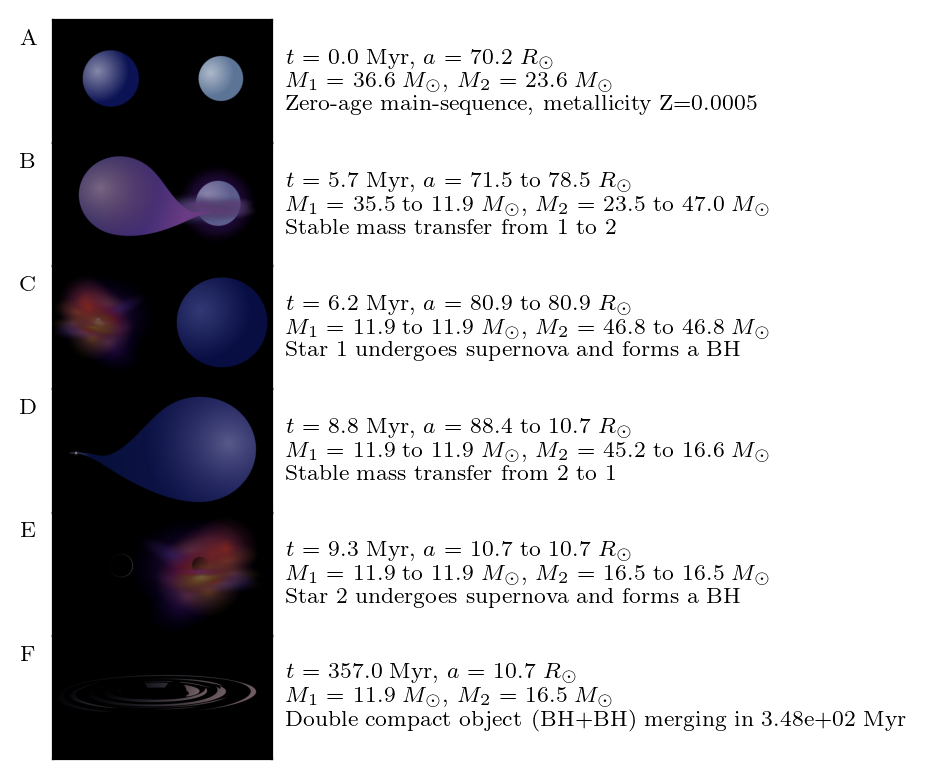

In [80]:
RawData = df_detailed_tides
tf = tempfile.TemporaryFile()
Data = h5.File(tf, 'w')
maskRecordType4 = RawData['Record_Type'] == 4     # Filter first for only end-of-timestep events
for key in RawData.keys():
    Data.create_dataset(key, data=RawData[key][maskRecordType4])

### Collect the important events in the detailed evolution
events = det_evo.allEvents(Data).allEvents                 # Calculate the events here, for use in plot sizing parameters
det_evo.printEvolutionaryHistory(events=events)
# det_evo.makeDetailedPlots(Data, events, outdir=None, show=True)
print("Merges Hubble Time?:", df_dco_tides['Merges_Hubble_Time'].values.astype(bool))
det_evo.plotVanDenHeuvel(events, outdir=None, use_latex=True)

In [50]:
df_detailed_tides['Period(1)'] = (2 * np.pi / (df_detailed_tides['Omega(1)'].values / u.s)).to(u.day)
df_detailed_tides['Period(2)'] = (2 * np.pi / (df_detailed_tides['Omega(2)'].values / u.s)).to(u.day)

omega_orb = np.sqrt(c.G * (df_detailed_tides['Mass(1)'].values * u.M_sun + df_detailed_tides['Mass(2)'].values * u.M_sun) / (df_detailed_tides['SemiMajorAxis'].values*u.AU)**3).to(1/u.s)
df_detailed_tides['Omega_Orb'] = omega_orb.value
df_detailed_tides['Period_Orb'] = (2 * np.pi / omega_orb).to(u.day)

df_detailed_tides_short = df_detailed_tides[columns_to_keep]

/opt/anaconda3/envs/tides_compas/lib/python3.11/site-packages/astropy/units/quantity.py:671: RuntimeWarning: divide by zero encountered in divide
  result = super().__array_ufunc__(function, method, *arrays, **kwargs)


In [27]:
# st_change_idx = np.where((df_detailed_tides['Stellar_Type(1)'] != df_detailed_tides['Stellar_Type(1)'].shift()) | (df_detailed_tides['Stellar_Type(2)'] != df_detailed_tides['Stellar_Type(2)'].shift()))[0]
# st_changes_with_buffer = np.concatenate([st_change_idx, st_change_idx+1])
# st_changes_with_buffer.sort()
# df_detailed_tides_short.iloc[st_changes_with_buffer] # the +1 is to get the row after the change, which is after tidal effects

In [28]:
df_dco_tides

,SEED,SemiMajorAxis@DCO,Eccentricity@DCO,Mass(1),Stellar_Type(1),Mass(2),Stellar_Type(2),Coalescence_Time,Time,Merges_Hubble_Time,Recycled_NS(1),Recycled_NS(2),Record_Type
0,1135,0.049567,0.0,11.87286,14,16.53033,14,348.143416,9.285365,1,0,0,1


In [51]:
df_sanity_tides = pd.read_csv(tides_DataPath+'/sanity_checks.csv', header=0)
df_sanity_tides = df_sanity_tides.rename(columns=lambda x: x.strip())
df_sanity_tides.head()

,SEED,Time,Dt,StellarType_1,StellarType_2,J_before,J_after,Jorb_before,Jorb_after,J1_before,J1_after,J2_before,J2_after,Omega_before,Omega,Omega1_before,Omega1,Omega2_before,Omega2,ecc_before,ecc,M1,R1,I1_before,I1_after,M2,R2,I2_before,I2_after,SemiMajorAxis_before,SemiMajorAxis_after,ImK10_1,ImK10_2,ImK12_1,ImK12_2,ImK22_1,ImK22_2,ImK32_1,ImK32_2,ImK10_1_dyn,ImK10_2_dyn,ImK12_1_dyn,ImK12_2_dyn,ImK22_1_dyn,ImK22_2_dyn,ImK32_1_dyn,ImK32_2_dyn,ImK10_1_eq,ImK10_2_eq,ImK12_1_eq,ImK12_2_eq,ImK22_1_eq,ImK22_2_eq,ImK32_1_eq,ImK32_2_eq,M1_core,R1_core,M2_core,R2_core,M1_conv_env,M1_conv_env_max,M2_conv_env,M2_conv_env_max,R1_conv_env_extent,R2_conv_env_extent,tau_conv1,tau_conv2,Lum_1,Lum_2,Temp_1,Temp_2,dadt1,dadt2,dOmegadt1,dOmegadt2,dedt1,dedt2,DaDt_tidal,DeDt_tidal,DOmegaDt_tidal,suggested_dt,dM1_winds,dM2_winds,dM1_MT,dM2_MT,ImK10_Zahn_Equilibrium1,ImK10_Zahn_Equilibrium2,ImK12_Zahn_Equilibrium1,ImK12_Zahn_Equilibrium2,ImK22_Zahn_Equilibrium1,ImK22_Zahn_Equilibrium2,ImK32_Zahn_Equilibrium1,ImK32_Zahn_Equilibrium2,ImK10_Zahn_Dynamical1,ImK10_Zahn_Dynamical2,ImK12_Zahn_Dynamical1,ImK12_Zahn_Dynamical2,ImK22_Zahn_Dynamical1,ImK22_Zahn_Dynamical2,ImK32_Zahn_Dynamical1,ImK32_Zahn_Dynamical2,DSemiMajorAxis1Dt_tidal_Zahn,DSemiMajorAxis2Dt_tidal_Zahn,DEccentricity1Dt_tidal_Zahn,DEccentricity2Dt_tidal_Zahn,DOmega1Dt_tidal_Zahn,DOmega2Dt_tidal_Zahn
0,1135,0.000000,0.000056,1,1,374.729,374.729,374.729,374.729,0.000000,0.000037,0.000000,0.000007,261.586,261.586,0.000000,0.012636,0.000000,0.006351,0.350775,0.350774,36.6118,6.10301,0.002949,0.002949,23.6347,4.73158,0.001144,0.001144,0.326353,0.326353,4.833800e-08,1.402600e-08,4.833800e-08,1.402600e-08,3.069270e-07,8.905960e-08,9.049240e-07,2.625780e-07,4.833800e-08,1.402600e-08,4.833800e-08,1.402600e-08,3.069270e-07,8.905960e-08,9.049240e-07,2.625780e-07,0,0,0,0,0,0,0,0,20.7124,3.20676,11.4761,2.22310,0.0,0.0,0.0,0.0,0.0,0.0,0,0.0,175845.0,62806.3,8.28917,7.27776,-1.784130e-09,-3.479590e-10,0.000254,0.000127,-2.395400e-09,-4.671740e-10,1.82920,1.46437,0.010313,0.010313,-0.000005,-8.969480e-07,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,4.880360e-09,9.118570e-10,4.880360e-09,9.118570e-10,3.098840e-08,5.789930e-09,9.136410e-08,1.707070e-08,-1.801320e-10,-2.262140e-11,-2.418480e-10,-3.037180e-11,0.000026,0.000008
1,1135,0.000056,0.014071,1,1,374.722,374.722,374.722,374.714,0.000037,0.006898,0.000007,0.001345,261.574,261.600,0.012634,2.339030,0.006351,1.175770,0.350774,0.350745,36.6106,6.10292,0.002949,0.002949,23.6344,4.73157,0.001144,0.001144,0.326361,0.326339,4.832420e-08,1.402320e-08,4.831170e-08,1.402140e-08,3.068000e-07,8.903580e-08,9.045880e-07,2.625130e-07,4.832420e-08,1.402320e-08,4.831170e-08,1.402140e-08,3.068000e-07,8.903580e-08,9.045880e-07,2.625130e-07,0,0,0,0,0,0,0,0,20.7114,3.20665,11.4759,2.22307,0.0,0.0,0.0,0.0,0.0,0.0,0,0.0,175834.0,62805.1,8.28909,7.27773,-1.783130e-09,-3.478110e-10,0.000254,0.000127,-2.394010e-09,-4.669660e-10,1.83027,1.46522,0.010318,0.010318,-0.001189,-2.253050e-04,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,4.879240e-09,9.117210e-10,4.877990e-09,9.116030e-10,3.097730e-08,5.788690e-09,9.133520e-08,1.706740e-08,-1.800410e-10,-2.261300e-11,-2.417210e-10,-3.035990e-11,0.000026,0.000008
2,1135,0.014127,0.014064,1,1,374.715,374.715,374.707,374.699,0.006896,0.013769,0.001345,0.002704,261.588,261.614,2.334010,4.659960,1.174110,2.359810,0.350745,0.350715,36.6094,6.10891,0.002955,0.002955,23.6342,4.73478,0.001146,0.001146,0.326346,0.326324,4.743010e-08,1.384730e-08,4.520650e-08,1.351830e-08,2.940500e-07,8.687640e-08,8.739120e-07,2.571690e-07,4.743010e-08,1.384730e-08,4.520650e-08,1.351830e-08,2.940500e-07,8.687640e-08,8.739120e-07,2.571690e-07,0,0,0,0,0,0,0,0,20.6897,3.20120,11.4679,2.22053,0.0,0.0,0.0,0.0,0.0,0.0,0,0.0,176058.0,62860.5,8.28766,7.27687,-1.730620e-09,-3.418400e-10,0.000246,0.000125,-2.325550e-09,-4.591760e-10,1.88572,1.50822,0.010655,0.010655,-0.001192,-2.256240e-04,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,4.898900e-09,9.143190e-10,4.669230e-09,8.925960e-10,3

In [53]:
df_sanity_tides['SemiMajorAxis_Rsun'] = (df_sanity_tides['SemiMajorAxis_after'].values * u.AU).to(u.R_sun)
df_sanity_tides['Period1'] = (2 * np.pi / (df_sanity_tides['Omega1'].values / u.yr)).to(u.day)
df_sanity_tides['Period2'] = (2 * np.pi / (df_sanity_tides['Omega2'].values / u.yr)).to(u.day)
df_sanity_tides['Period_orb'] = (2 * np.pi / (df_sanity_tides['Omega'].values / u.yr)).to(u.day)


df_sanity_tides_short = df_sanity_tides[columns_to_keep_sanity]

df_sanity_tides.iloc[np.where(df_sanity_tides['StellarType_2'] == 7)]

,SEED,Time,Dt,StellarType_1,StellarType_2,J_before,J_after,Jorb_before,Jorb_after,J1_before,J1_after,J2_before,J2_after,Omega_before,Omega,Omega1_before,Omega1,Omega2_before,Omega2,ecc_before,ecc,M1,R1,I1_before,I1_after,M2,R2,I2_before,I2_after,SemiMajorAxis_before,SemiMajorAxis_after,ImK10_1,ImK10_2,ImK12_1,ImK12_2,ImK22_1,ImK22_2,ImK32_1,ImK32_2,ImK10_1_dyn,ImK10_2_dyn,ImK12_1_dyn,ImK12_2_dyn,ImK22_1_dyn,ImK22_2_dyn,ImK32_1_dyn,ImK32_2_dyn,ImK10_1_eq,ImK10_2_eq,ImK12_1_eq,ImK12_2_eq,ImK22_1_eq,ImK22_2_eq,ImK32_1_eq,ImK32_2_eq,M1_core,R1_core,M2_core,R2_core,M1_conv_env,M1_conv_env_max,M2_conv_env,M2_conv_env_max,R1_conv_env_extent,R2_conv_env_extent,tau_conv1,tau_conv2,Lum_1,Lum_2,Temp_1,Temp_2,dadt1,dadt2,dOmegadt1,dOmegadt2,dedt1,dedt2,DaDt_tidal,DeDt_tidal,DOmegaDt_tidal,suggested_dt,dM1_winds,dM2_winds,dM1_MT,dM2_MT,ImK10_Zahn_Equilibrium1,ImK10_Zahn_Equilibrium2,ImK12_Zahn_Equilibrium1,ImK12_Zahn_Equilibrium2,ImK22_Zahn_Equilibrium1,ImK22_Zahn_Equilibrium2,ImK32_Zahn_Equilibrium1,ImK32_Zahn_Equilibrium2,ImK10_Zahn_Dynamical1,ImK10_Zahn_Dynamical2,ImK12_Zahn_Dynamical1,ImK12_Zahn_Dynamical2,ImK22_Zahn_Dynamical1,ImK22_Zahn_Dynamical2,ImK32_Zahn_Dynamical1,ImK32_Zahn_Dynamical2,DSemiMajorAxis1Dt_tidal_Zahn,DSemiMajorAxis2Dt_tidal_Zahn,DEccentricity1Dt_tidal_Zahn,DEccentricity2Dt_tidal_Zahn,DOmega1Dt_tidal_Zahn,DOmega2Dt_tidal_Zahn,SemiMajorAxis_Rsun,Period1,Period2,Period_orb
3858,1135,8.80936,8.587440e-07,14,7,51.8001,51.8001,51.7861,51.7861,0.000439,0.000439,0.013544,0.013544,3039.30,3039.30,1.687250e+09,1.687250e+09,229.574,229.574,0.0,0.0,11.8729,0.00005,2.602860e-13,2.602860e-13,16.6497,1.28002,0.000059,0.000059,0.049583,0.049583,0.0,0.000000e+00,0.0,0.000000e+00,0.0,0.000000e+00,0.0,0.000000e+00,0.0,0.000000e+00,0.0,0.000000e+00,0.0,0.000000e+00,0.0,0.000000e+00,0,0,0,0,0,0,0,0,11.8729,0.00005,16.6497,1.280020,0.0,0.0,0.0,0.0,0.0,0.0,0,0.0,1.000000e-10,356068.0,0.445697,21.5911,-0.0,-0.000000e+00,0.0,0.000000e+00,-0.0,-0.0,inf,inf,inf,inf,0.0,0.000000e+00,0.000392,-28.5231,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2.867660e-27,-1.995110e-09,-3.790460e-11,1.289110e-09,-3.790450e-11,1.027440e-08,-3.790440e-11,3.254260e-08,5.638850e-35,-8.261070e-11,0.0,-0.0,-1.131330e-19,0.000731,10.661961,0.000001,9.996487,0.755086
3859,1135,8.80936,3.585560e-03,14,7,51.7992,51.7992,51.7852,51.7852,0.000439,0.000439,0.013541,0.013541,3039.15,3039.15,1.687250e+09,1.687250e+09,229.532,229.532,0.0,0.0,11.8729,0.00005,2.602860e-13,2.602860e-13,16.6490,1.27999,0.000059,0.000059,0.049584,0.049584,0.0,0.000000e+00,0.0,0.000000e+00,0.0,0.000000e+00,0.0,0.000000e+00,0.0,0.000000e+00,0.0,0.000000e+00,0.0,0.000000e+00,0.0,0.000000e+00,0,0,0,0,0,0,0,0,11.8729,0.00005,16.6490,1.279990,0.0,0.0,0.0,0.0,0.0,0.0,0,0.0,1.000000e-10,356043.0,0.445697,21.5910,-0.0,-0.000000e+00,0.0,0.000000e+00,-0.0,-0.0,inf,inf,inf,inf,0.0,-6.858660e-04,0.000000,0.0000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2.867290e-27,-1.994530e-09,-3.790460e-11,1.288820e-09,-3.790450e-11,1.027170e-08,-3.790440e-11,3.253370e-08,5.637800e-35,-8.257030e-11,0.0,-0.0,-1.131070e-19,0.000731,10.662219,0.000001,9.998316,0.755123
3860,1135,8.81295,3.585540e-03,14,7,51.7983,51.7983,51.7843,51.7825,0.000439,0.000439,0.013537,0.015333,3039.01,3039.32,1.687250e+09,1.687260e+09,229.031,259.422,0.0,0.0,11.8729,0.00005,2.602860e-13,2.602860e-13,16.6483,1.28124,0.000059,0.000059,0.049585,0.049582,0.0,2.674470e-05,0.0,1.729940e-05,0.0,1.377970e-04,0.0,4.363770e-04,0.0,2.674470e-05,0.0,1.729940e-05,0.0,1.377970e-04,0.0,4.363770e-04,0,0,0,0,0,0,0,0,11.8729,0.00005,16.5794,1.271480,0.0,0.0,0.0,0.0,0.0,0.0,0,0.0,1.000000e-10,357238.0,0.445697,21.5985,-0.0,-1.113000e-06,0.0,9.832980e+00,-0.0,-0.0,4.455140e-04,inf,3.090630e-06,3.090630e-06,0.0,-6.889940e-04,0.000000,0.0000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2.866920e-27,-2.001940e-09,-3.790460e-11,1.294920e-09,-3.790450e-11,1.031460e-08,-3.790440e-11,3.266430e-08,5.636750e-35,-8.331160e-11,0.0,-0.0,-1.130820e-19,0.000736,10.661724,0.000001,8.846333,0.755081
3861,1135,8.81653

In [31]:
st_change_idx = np.where((df_sanity_tides_short['StellarType_1'] != df_sanity_tides_short['StellarType_1'].shift()) | (df_sanity_tides_short['StellarType_2'] != df_sanity_tides_short['StellarType_2'].shift()))[0]
st_changes_with_buffer = np.concatenate([st_change_idx, st_change_idx-1])
st_changes_with_buffer.sort()
df_sanity_tides_short.iloc[st_changes_with_buffer][1:]

,Time,M1,M2,R1,R2,SemiMajorAxis_Rsun,ecc,StellarType_1,StellarType_2,Period1,Period2,Period_orb,J1_after,J2_after,Jorb_after,dM1_MT,dM2_MT,ImK22_1,ImK22_2,ImK22_1_dyn,ImK22_2_dyn,ImK22_1_eq,ImK22_2_eq,ImK22_Zahn_Equilibrium1,ImK22_Zahn_Equilibrium2,ImK22_Zahn_Dynamical1,ImK22_Zahn_Dynamical2
0,0.00000,36.6118,23.6347,6.10301,4.73158,70.176389,3.507740e-01,1,1,181622.975652,3.613465e+05,8.773151,0.000037,0.000007,374.7290,0.000000,0.0000,3.069270e-07,8.905960e-08,3.069270e-07,8.905960e-08,0,0,0.0,0.000000e+00,3.098840e-08,5.789930e-09
1379,5.65109,35.4554,23.4764,15.22220,7.15803,71.475183,3.489320e-01,1,1,132.877855,5.164175e+01,9.117842,0.306864,0.115606,368.0890,0.000000,0.0000,2.014320e-13,3.795440e-11,2.014320e-13,3.795440e-11,0,0,0.0,0.000000e+00,8.530470e-07,1.613670e-08
1380,5.65109,35.4552,23.4764,14.88250,7.15803,71.475398,3.489320e-01,2,1,84.825057,5.164186e+01,9.117914,0.306848,0.115606,368.0880,0.000000,0.0000,2.012570e-13,3.795350e-11,2.012570e-13,3.795350e-11,0,0,inf,0.000000e+00,6.956400e-07,1.613640e-08
1563,5.65216,35.4549,23.4764,19.31470,7.15903,71.475828,3.489320e-01,2,1,142.353234,5.165663e+01,9.118023,0.306816,0.115605,368.0870,0.000000,0.0000,6.289790e-14,3.788080e-11,6.289790e-14,3.788080e-11,0,0,inf,0.000000e+00,2.240020e-06,1.614730e-08
1564,5.65216,11.9395,46.9918,1.04452,8.18978,78.546301,0.000000e+00,7,1,142.478732,3.960346e-01,10.503945,0.000454,39.499900,277.5390,-23.515400,23.5154,0.000000e+00,-1.139790e-04,0.000000e+00,-1.139790e-04,0,0,0.0,0.000000e+00,2.479020e-12,-5.113550e-04
1752,6.22752,11.8757,46.7997,1.04110,8.85768,80.808224,0.000000e+00,7,1,145.858233,5.040940e-01,10.984747,0.000438,36.152100,279.4670,0.000000,0.0000,0.000000e+00,-1.555830e-05,0.000000e+00,-1.555830e-05,0,0,0.0,0.000000e+00,2.144120e-12,-3.572120e-04
1753,6.22752,11.8755,46.7989,1.04110,8.85760,80.817900,0.000000e+00,8,1,43.339964,5.042779e-01,10.986851,0.000438,36.137800,279.4760,0.000000,0.0000,0.000000e+00,-1.555470e-05,0.000000e+00,-1.555470e-05,0,0,0.0,0.000000e+00,1.211370e-12,-3.571250e-04
1828,6.24693,11.8725,46.7924,1.12914,8.88425,80.904558,0.000000e+00,8,1,44.297748,5.090339e-01,11.005397,0.000435,36.010900,279.5390,0.000000,0.0000,0.000000e+00,-1.442900e-05,0.000000e+00,-1.442900e-05,0,0,0.0,0.000000e+00,1.697690e-12,-3.518270e-04
1829,6.24713,11.8725,46.7923,0.00005,8.88452,80.905419,0.000000e+00,14,1,0.000001,5.090836e-01,11.005608,0.000435,36.009500,279.5400,0.000000,0.0000,0.000000e+00,-1.441810e-05,0.000000e+00,-1.441810e-05,0,0,0.0,0.000000e+00,-3.697060e-11,-3.517740e-04
3036,8.80735,11.8725,45.1744,0.00005,17.94910,88.416277,0.000000e+00,14,1,0.000001,2.635707e+00,12.750197,0.000435,27.405900,286.0960,0.000000,0.0000,0.000000e+00,-6.167500e-12,0.000000e+00,-6.167500e-12,0,0,0.0,0.000000e+00,-3.697060e-11,-4.238430e-05


### Perfect Tides

Time (Myr), Event,                            M1 (M_o), type1, M2 (M_o), type2, a (R_o),   e
  0.000056   Zero-age main-sequence, metallicity Z=0.0005   36.612     1     23.635     1     70.176  0.351
  5.651091   Star 1: MS->HG                    35.455     2     23.476     1     65.601  0.285
  5.652203   Stable mass transfer from 1 to 2   11.941     7     46.990     1     79.451  0.000
  5.652203   Star 1: HG->HeMS                  11.941     7     46.990     1     79.451  0.000
  6.227520   Star 1: HeMS->HeHG                11.877     8     46.798     1     82.078  0.000
  6.247319   Star 1 undergoes supernova and forms a BH   11.874    14     46.791     1     82.841  0.000
  8.807381   Star 2: MS->HG                    11.874    14     45.173     2    100.358  0.000
  8.809660   Stable mass transfer from 2 to 1   11.874    14     16.668     7     12.064  0.000
  8.809660   Star 2: HG->HeMS                  11.874    14     16.668     7     12.064  0.000
  9.281002   Star 2: HeMS->

(<Figure size 900x480 with 6 Axes>,
  <COMPAS.compas_python_utils.detailed_evolution_plotter.plot_detailed_evolution.Event at 0x16fbb87d0>])

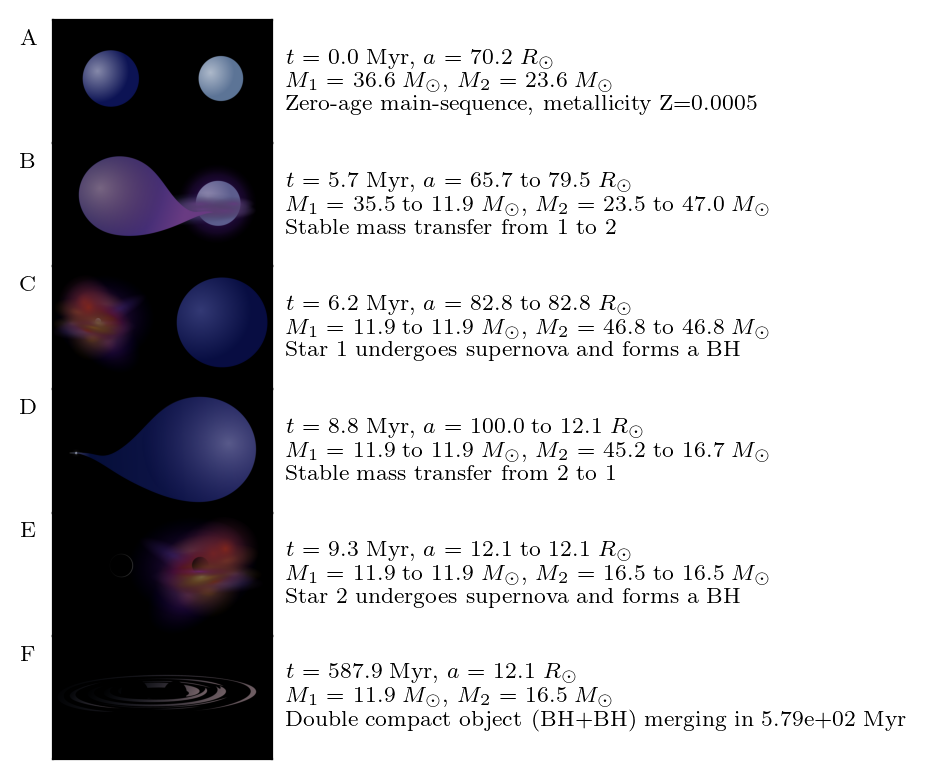

In [7]:
RawData = df_detailed_perfect
tf = tempfile.TemporaryFile()
Data = h5.File(tf, 'w')
maskRecordType4 = RawData['Record_Type'] == 4     # Filter first for only end-of-timestep events
for key in RawData.keys():
    Data.create_dataset(key, data=RawData[key][maskRecordType4])

### Collect the important events in the detailed evolution
events = det_evo.allEvents(Data).allEvents                 # Calculate the events here, for use in plot sizing parameters
det_evo.printEvolutionaryHistory(events=events)
# det_evo.makeDetailedPlots(Data, events, outdir=None, show=True)
# print("Merges Hubble Time?:", df_dco_perfect['Merges_Hubble_Time'].values.astype(bool))
det_evo.plotVanDenHeuvel(events, outdir=None, use_latex=True)

In [32]:
df_detailed_perfect['Period(1)'] = (2 * np.pi / (df_detailed_perfect['Omega(1)'].values / u.s)).to(u.day)
df_detailed_perfect['Period(2)'] = (2 * np.pi / (df_detailed_perfect['Omega(2)'].values / u.s)).to(u.day)

omega_orb = np.sqrt(c.G * (df_detailed_perfect['Mass(1)'].values * u.M_sun + df_detailed_perfect['Mass(2)'].values * u.M_sun) / (df_detailed_perfect['SemiMajorAxis'].values*u.AU)**3).to(1/u.s)
df_detailed_perfect['Omega_Orb'] = omega_orb.value
df_detailed_perfect['Period_Orb'] = (2 * np.pi / omega_orb).to(u.day)

df_detailed_perfect_short = df_detailed_perfect[columns_to_keep]

/opt/anaconda3/envs/tides_compas/lib/python3.11/site-packages/astropy/units/quantity.py:671: RuntimeWarning: divide by zero encountered in divide
  result = super().__array_ufunc__(function, method, *arrays, **kwargs)
/opt/anaconda3/envs/tides_compas/lib/python3.11/site-packages/astropy/units/quantity.py:671: RuntimeWarning: divide by zero encountered in divide
  result = super().__array_ufunc__(function, method, *arrays, **kwargs)


In [33]:
# st_change_idx = np.where((df_detailed_perfect_short['Stellar_Type(1)'] != df_detailed_perfect_short['Stellar_Type(1)'].shift()) | (df_detailed_perfect_short['Stellar_Type(2)'] != df_detailed_perfect_short['Stellar_Type(2)'].shift()))[0]
# st_changes_with_buffer = np.concatenate([st_change_idx, st_change_idx+1])
# st_changes_with_buffer.sort()
# df_detailed_perfect_short.iloc[st_changes_with_buffer]


In [34]:
df_dco_perfect

,SEED,SemiMajorAxis@DCO,Eccentricity@DCO,Mass(1),Stellar_Type(1),Mass(2),Stellar_Type(2),Coalescence_Time,Time,Merges_Hubble_Time,Recycled_NS(1),Recycled_NS(2),Record_Type
0,1135,0.056323,0.0,11.874137,14,16.548666,14,579.332189,9.285364,1,0,0,1


In [35]:
df_sanity_perfect = pd.read_csv(perfect_DataPath+'/sanity_checks.csv', header=0)
df_sanity_perfect = df_sanity_perfect.rename(columns=lambda x: x.strip())

In [37]:
df_sanity_perfect['SemiMajorAxis_Rsun'] = (df_sanity_perfect['SemiMajorAxis_after'].values * u.AU).to(u.R_sun)
df_sanity_perfect['Period1'] = (2 * np.pi / (df_sanity_perfect['Omega1'].values / u.yr)).to(u.day)
df_sanity_perfect['Period2'] = (2 * np.pi / (df_sanity_perfect['Omega2'].values / u.yr)).to(u.day)
df_sanity_perfect['Period_orb'] = (2 * np.pi / (df_sanity_perfect['Omega'].values / u.yr)).to(u.day)


df_sanity_perfect_short = df_sanity_perfect[columns_to_keep_sanity]

In [38]:
st_change_idx = np.where((df_sanity_perfect_short['StellarType_1'] != df_sanity_perfect_short['StellarType_1'].shift()) | (df_sanity_perfect_short['StellarType_2'] != df_sanity_perfect_short['StellarType_2'].shift()))[0]
st_changes_with_buffer = np.concatenate([st_change_idx, st_change_idx-1])
st_changes_with_buffer.sort()
df_sanity_perfect_short.iloc[st_changes_with_buffer][1:]


,Time,M1,M2,R1,R2,SemiMajorAxis_Rsun,ecc,StellarType_1,StellarType_2,Period1,Period2,Period_orb,J1_after,J2_after,Jorb_after,dM1_MT,dM2_MT,ImK22_1,ImK22_2,ImK22_1_dyn,ImK22_2_dyn,ImK22_1_eq,ImK22_2_eq,ImK22_Zahn_Equilibrium1,ImK22_Zahn_Equilibrium2,ImK22_Zahn_Dynamical1,ImK22_Zahn_Dynamical2
0,0.00000,36.6118,23.6347,6.10301,4.73158,70.176389,3.507750e-01,1,1,1.599803e+06,4.943005e+06,8.773151,0.000004,5.312930e-07,374.7290,0.000000,0.0000,3.069270e-07,8.905960e-08,3.069270e-07,8.905960e-08,0,0,0.0,0.000000e+00,3.098840e-08,5.789930e-09
1379,5.65109,35.4554,23.4764,15.22220,7.15803,65.600505,2.850340e-01,1,1,4.492417e+00,2.255795e+01,8.017179,9.076520,2.646580e-01,360.6790,0.000000,0.0000,-1.796880e-13,2.783980e-11,-1.796880e-13,2.783980e-11,0,0,0.0,0.000000e+00,-7.609660e-07,1.183640e-08
1380,5.65109,35.4552,23.4764,14.88250,7.15803,65.614267,2.850760e-01,2,1,2.878103e+00,2.255640e+01,8.019700,9.043600,2.646740e-01,360.7110,0.000000,0.0000,-1.829490e-12,2.783850e-11,-1.829490e-12,2.783850e-11,0,0,-inf,0.000000e+00,-6.323600e-06,1.183590e-08
1572,5.65220,35.4548,23.4764,19.48930,7.15907,65.693184,2.850520e-01,2,1,5.037532e+00,2.254798e+01,8.034215,8.826600,2.648510e-01,360.9270,0.000000,0.0000,-2.518160e-14,2.752030e-11,-2.518160e-14,2.752030e-11,0,0,-inf,0.000000e+00,-9.719740e-07,1.173200e-08
1573,5.65220,11.9408,46.9904,1.04459,8.18971,79.451371,0.000000e+00,7,1,5.041959e+00,3.960373e-01,10.685988,0.012826,3.949790e+01,279.1570,-23.514100,23.5141,0.000000e+00,-1.141590e-04,0.000000e+00,-1.141590e-04,0,0,0.0,0.000000e+00,-3.925510e-12,-5.122230e-04
1761,6.22752,11.8771,46.7983,1.04117,8.85755,82.077774,0.000000e+00,7,1,5.163210e+00,5.126132e-01,11.244658,0.012376,3.554930e+01,281.6780,0.000000,0.0000,0.000000e+00,-1.488970e-05,0.000000e+00,-1.488970e-05,0,0,0.0,0.000000e+00,-3.842410e-12,-3.418570e-04
1762,6.22752,11.8768,46.7976,1.04117,8.85747,82.090891,0.000000e+00,8,1,1.534118e+00,5.128836e-01,11.247413,0.012370,3.552940e+01,281.6920,0.000000,0.0000,0.000000e+00,-1.488610e-05,0.000000e+00,-1.488610e-05,0,0,0.0,0.000000e+00,-3.404580e-10,-3.417710e-04
1837,6.24693,11.8738,46.7910,1.12922,8.88412,82.831031,0.000000e+00,8,1,1.567984e+00,5.346180e-01,11.400790,0.012294,3.428560e+01,282.8710,0.000000,0.0000,0.000000e+00,-1.265190e-05,0.000000e+00,-1.265190e-05,0,0,0.0,0.000000e+00,-4.427100e-10,-3.084910e-04
1838,6.24712,11.8738,46.7910,0.00005,8.88439,82.840708,1.110540e-16,14,1,4.860170e-08,5.349059e-01,11.402829,0.012293,3.426920e+01,282.8870,0.000000,0.0000,0.000000e+00,-1.262700e-05,0.000000e+00,-1.262700e-05,0,0,0.0,0.000000e+00,-2.737680e-07,-3.080700e-04
3045,8.80738,11.8738,45.1732,0.00005,17.94880,100.358302,1.412980e-16,14,1,4.860170e-08,7.081620e+00,15.418795,0.012293,1.019950e+01,304.8310,0.000000,0.0000,0.000000e+00,-1.590600e-13,0.000000e+00,-1.590600e-13,0,0,0.0,0.000000e+00,-2.737680e-07,-1.093030e-06


# CE binary not able to spin up

In [54]:
notides_DataPath = 'sim_data/ce_notides'
tides_DataPath = 'sim_data/ce_realistic'
# perfect_DataPath = 'sim_data/ce_perfect'
perfect_DataPath = 'sim_data/ce_z77'

# # --------------

df_detailed_notides = pd.read_csv(notides_DataPath+'/Detailed_Output/BSE_Detailed_Output_0.csv', skiprows=2, header=0)
df_detailed_notides = df_detailed_notides.rename(columns=lambda x: x.strip())

df_detailed_tides = pd.read_csv(tides_DataPath+'/Detailed_Output/BSE_Detailed_Output_0.csv', skiprows=2, header=0, low_memory=False)
df_detailed_tides = df_detailed_tides.rename(columns=lambda x: x.strip())

df_detailed_perfect = pd.read_csv(perfect_DataPath+'/Detailed_Output/BSE_Detailed_Output_0.csv', skiprows=2, header=0, low_memory=False)
df_detailed_perfect = df_detailed_perfect.rename(columns=lambda x: x.strip())



df_dco_notides = pd.read_csv(notides_DataPath+'/BSE_Double_Compact_Objects.csv', skiprows=2, header=0)
df_dco_notides = df_dco_notides.rename(columns=lambda x: x.strip())

df_dco_tides = pd.read_csv(tides_DataPath+'/BSE_Double_Compact_Objects.csv', skiprows=2, header=0)
df_dco_tides = df_dco_tides.rename(columns=lambda x: x.strip())

df_dco_perfect = pd.read_csv(perfect_DataPath+'/BSE_Double_Compact_Objects.csv', skiprows=2, header=0)
df_dco_perfect = df_dco_perfect.rename(columns=lambda x: x.strip())


### Realistic Tides

Time (Myr), Event,                            M1 (M_o), type1, M2 (M_o), type2, a (R_o),   e
  0.000073   Zero-age main-sequence, metallicity Z=0.0002   26.708     1     24.138     1    502.454  0.039
  7.302147   Star 1: MS->HG                    26.376     2     23.937     1    507.779  0.039
  7.313064   Star 1: HG->CHeB                  26.375     4     23.936     1    507.794  0.039
  7.879652   Stable mass transfer from 1 to 2    9.959     7     25.019     1   1254.580  0.000
  7.879652   Star 1: CHeB->HeMS                 9.959     7     25.019     1   1254.580  0.000
  8.001234   Star 1: HeMS->HeHG                 9.953     8     25.011     1   1255.142  0.000
  8.029444   Star 1 undergoes supernova and forms a BH    9.951    14     25.009     1   1255.289  0.000
  8.385335   Star 2: MS->HG                     9.951    14     24.986     2   1256.328  0.000
  8.397371   Star 2: HG->CHeB                   9.951    14     24.985     4   1256.365  0.000
  9.112222   Common envelope

(<Figure size 900x480 with 6 Axes>,
  <COMPAS.compas_python_utils.detailed_evolution_plotter.plot_detailed_evolution.Event at 0x170f44790>])

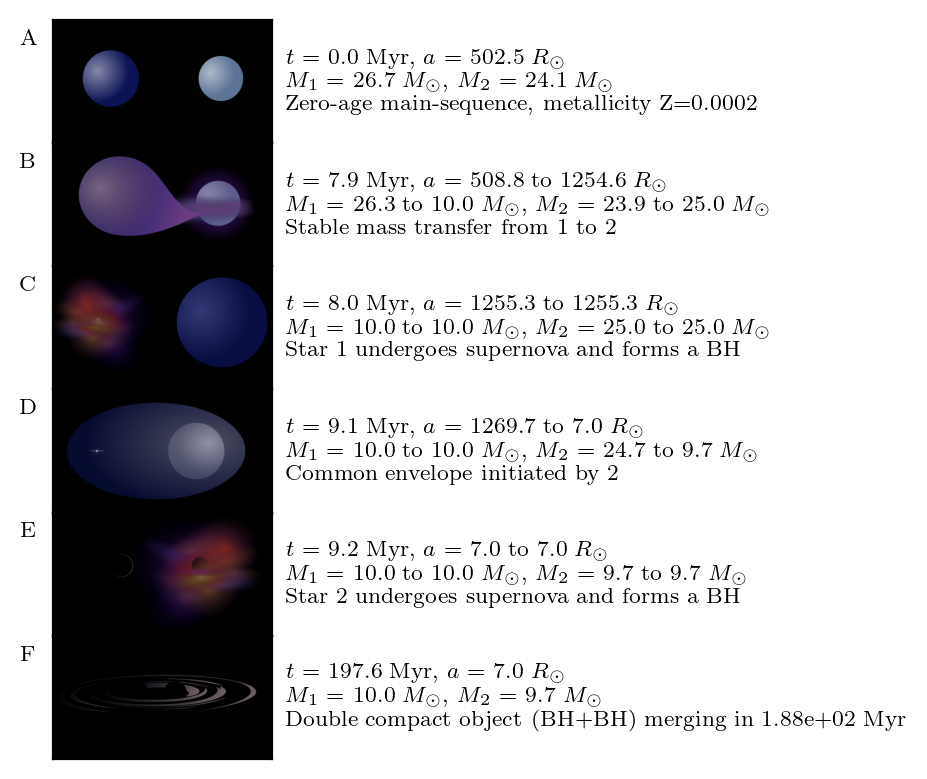

In [95]:
RawData = df_detailed_tides
tf = tempfile.TemporaryFile()
Data = h5.File(tf, 'w')
maskRecordType4 = RawData['Record_Type'] == 4     # Filter first for only end-of-timestep events
for key in RawData.keys():
    Data.create_dataset(key, data=RawData[key][maskRecordType4])

### Collect the important events in the detailed evolution
events = det_evo.allEvents(Data).allEvents                 # Calculate the events here, for use in plot sizing parameters
det_evo.printEvolutionaryHistory(events=events)
# det_evo.makeDetailedPlots(Data, events, outdir=None, show=True)
print("Merges Hubble Time?:", df_dco_tides['Merges_Hubble_Time'].values.astype(bool))
det_evo.plotVanDenHeuvel(events, outdir=None, use_latex=True)

In [96]:
df_sanity_tides = pd.read_csv(tides_DataPath+'/sanity_checks.csv', header=0)
df_sanity_tides = df_sanity_tides.rename(columns=lambda x: x.strip())

df_sanity_tides['SemiMajorAxis_Rsun'] = (df_sanity_tides['SemiMajorAxis_after'].values * u.AU).to(u.R_sun)
df_sanity_tides['Period1'] = (2 * np.pi / (df_sanity_tides['Omega1'].values / u.yr)).to(u.day)
df_sanity_tides['Period2'] = (2 * np.pi / (df_sanity_tides['Omega2'].values / u.yr)).to(u.day)
df_sanity_tides['Period_orb'] = (2 * np.pi / (df_sanity_tides['Omega'].values / u.yr)).to(u.day)

df_sanity_tides_short = df_sanity_tides[columns_to_keep_sanity]

/opt/anaconda3/envs/tides_compas/lib/python3.11/site-packages/astropy/units/quantity.py:671: RuntimeWarning: divide by zero encountered in divide
  result = super().__array_ufunc__(function, method, *arrays, **kwargs)
/opt/anaconda3/envs/tides_compas/lib/python3.11/site-packages/astropy/units/quantity.py:671: RuntimeWarning: divide by zero encountered in divide
  result = super().__array_ufunc__(function, method, *arrays, **kwargs)


In [97]:
st_change_idx = np.where((df_sanity_tides_short['StellarType_1'] != df_sanity_tides_short['StellarType_1'].shift()) | (df_sanity_tides_short['StellarType_2'] != df_sanity_tides_short['StellarType_2'].shift()))[0]
st_changes_with_buffer = np.concatenate([st_change_idx, st_change_idx-1])
st_changes_with_buffer.sort()
df_sanity_tides_short.iloc[st_changes_with_buffer][1:]

,Time,M1,M2,R1,R2,SemiMajorAxis_Rsun,ecc,StellarType_1,StellarType_2,Period1,Period2,Period_orb,J1_after,J2_after,Jorb_after,dM1_MT,dM2_MT,ImK22_1,ImK22_2,ImK12_1_dyn,ImK12_2_dyn,ImK12_1_eq,ImK12_2_eq
0,0.00000,26.70760,24.13840,4.800230,4.521210,502.452736,3.941130e-02,1,1,inf,inf,182.957981,0.000000e+00,0.000000e+00,867.6690,0.000,0.00000,5.169080e-11,3.846470e-11,8.140790e-12,6.057810e-12,0,0
1288,7.30215,26.37570,23.93700,11.701300,10.037000,507.779083,3.941130e-02,1,1,2.474882e+11,2.161911e+11,186.856441,7.242330e-11,5.536070e-11,858.7440,0.000,0.00000,5.360000e-17,2.817450e-16,8.441480e-18,4.437200e-17,0,0
1289,7.30215,26.37560,23.93700,11.495300,10.037000,507.781233,3.941130e-02,2,1,1.673253e+11,2.161891e+11,186.857962,7.242280e-11,5.536120e-11,858.7420,0.000,0.00000,5.857600e-17,2.817400e-16,9.225150e-18,4.437120e-17,0,0
2368,7.31306,26.37480,23.93640,35.714000,10.071500,507.794135,3.941130e-02,2,1,1.594590e+12,2.176571e+11,186.867091,7.241840e-11,5.536560e-11,858.7190,0.000,0.00000,2.200730e-19,2.715760e-16,3.465930e-20,4.277060e-17,0,0
2369,7.31306,26.37470,23.93640,35.712200,10.071500,507.796285,3.941130e-02,4,1,1.594435e+12,2.176510e+11,186.868613,7.241750e-11,5.536650e-11,858.7150,0.000,0.00000,2.201250e-19,2.715670e-16,3.466740e-20,4.276920e-17,0,0
4118,7.87954,26.30450,23.90580,189.173000,12.506800,508.815538,3.941130e-02,4,1,4.042304e+13,3.316680e+11,187.620255,7.182660e-11,5.595740e-11,857.0530,0.000,0.00000,2.761620e-22,3.104990e-17,4.349270e-23,4.890050e-18,0,0
4119,7.87960,9.95851,25.01890,1.022830,11.195800,1254.579308,0.000000e+00,7,1,4.046281e+13,1.949899e+00,870.338032,1.277930e-15,7.982270e+00,639.3620,-16.346,1.11311,5.203730e-19,-2.681580e-11,8.195360e-20,-2.689610e-11,0,0
4211,8.00123,9.95271,25.01100,0.933968,11.750800,1255.142693,0.000000e+00,7,1,3.384927e+13,2.151937e+00,871.094549,1.272970e-15,7.965290e+00,639.0540,0.000,0.00000,0.000000e+00,-1.270810e-11,0.000000e+00,-1.275010e-11,0,0
4212,8.00123,9.95260,25.01080,0.933966,11.750800,1255.151294,0.000000e+00,8,1,1.067913e+13,2.151998e+00,871.107775,1.272680e-15,7.964990e+00,639.0480,0.000,0.00000,0.000000e+00,-1.270710e-11,0.000000e+00,-1.274910e-11,0,0
4338,8.02915,9.95090,25.00910,1.067170,11.889200,1255.286764,0.000000e+00,8,1,1.163529e+13,2.203806e+00,871.292981,1.267630e-15,7.961390e+00,638.9620,0.000,0.00000,0.000000e+00,-1.063020e-11,0.000000e+00,-1.066620e-11,0,0


### Notides

Time (Myr), Event,                            M1 (M_o), type1, M2 (M_o), type2, a (R_o),   e
  0.000073   Zero-age main-sequence, metallicity Z=0.0002   26.708     1     24.138     1    502.454  0.039
  7.302147   Star 1: MS->HG                    26.376     2     23.937     1    507.779  0.039
  7.313064   Star 1: HG->CHeB                  26.375     4     23.936     1    507.794  0.039
  7.879652   Stable mass transfer from 1 to 2    9.959     7     25.019     1   1254.580  0.000
  7.879652   Star 1: CHeB->HeMS                 9.959     7     25.019     1   1254.580  0.000
  8.001234   Star 1: HeMS->HeHG                 9.953     8     25.011     1   1255.142  0.000
  8.029444   Star 1 undergoes supernova and forms a BH    9.951    14     25.009     1   1255.289  0.000
  8.385335   Star 2: MS->HG                     9.951    14     24.986     2   1256.328  0.000
  8.397371   Star 2: HG->CHeB                   9.951    14     24.985     4   1256.365  0.000
  9.112222   Common envelope

(<Figure size 900x480 with 6 Axes>,
  <COMPAS.compas_python_utils.detailed_evolution_plotter.plot_detailed_evolution.Event at 0x16fd85490>])

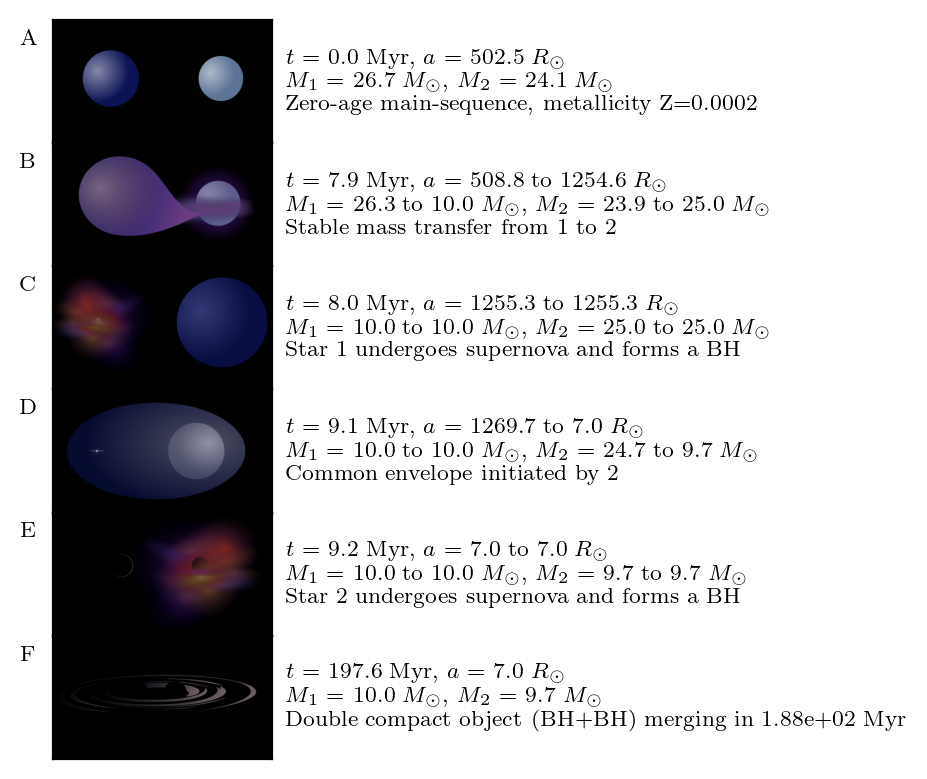

In [98]:
RawData = df_detailed_notides
tf = tempfile.TemporaryFile()
Data = h5.File(tf, 'w')
maskRecordType4 = RawData['Record_Type'] == 4     # Filter first for only end-of-timestep events
for key in RawData.keys():
    Data.create_dataset(key, data=RawData[key][maskRecordType4])

### Collect the important events in the detailed evolution
events = det_evo.allEvents(Data).allEvents                 # Calculate the events here, for use in plot sizing parameters
det_evo.printEvolutionaryHistory(events=events)
# det_evo.makeDetailedPlots(Data, events, outdir=None, show=True)
print("Merges Hubble Time?:", df_dco_tides['Merges_Hubble_Time'].values.astype(bool))
det_evo.plotVanDenHeuvel(events, outdir=None, use_latex=True)

In [99]:
df_sanity_notides = pd.read_csv(notides_DataPath+'/sanity_checks.csv', header=0)
df_sanity_notides = df_sanity_notides.rename(columns=lambda x: x.strip())

df_sanity_notides['SemiMajorAxis_Rsun'] = (df_sanity_notides['SemiMajorAxis_after'].values * u.AU).to(u.R_sun)
df_sanity_notides['Period1'] = (2 * np.pi / (df_sanity_notides['Omega1'].values / u.yr)).to(u.day)
df_sanity_notides['Period2'] = (2 * np.pi / (df_sanity_notides['Omega2'].values / u.yr)).to(u.day)
df_sanity_notides['Period_orb'] = (2 * np.pi / (df_sanity_notides['Omega'].values / u.yr)).to(u.day)

df_sanity_notides_short = df_sanity_notides[columns_to_keep_sanity]

/opt/anaconda3/envs/tides_compas/lib/python3.11/site-packages/astropy/units/quantity.py:671: RuntimeWarning: divide by zero encountered in divide
  result = super().__array_ufunc__(function, method, *arrays, **kwargs)
/opt/anaconda3/envs/tides_compas/lib/python3.11/site-packages/astropy/units/quantity.py:671: RuntimeWarning: divide by zero encountered in divide
  result = super().__array_ufunc__(function, method, *arrays, **kwargs)


In [100]:
st_change_idx = np.where((df_sanity_notides_short['StellarType_1'] != df_sanity_notides_short['StellarType_1'].shift()) | (df_sanity_notides_short['StellarType_2'] != df_sanity_notides_short['StellarType_2'].shift()))[0]
st_changes_with_buffer = np.concatenate([st_change_idx, st_change_idx-1])
st_changes_with_buffer.sort()
df_sanity_notides_short.iloc[st_changes_with_buffer][1:]

,Time,M1,M2,R1,R2,SemiMajorAxis_Rsun,ecc,StellarType_1,StellarType_2,Period1,Period2,Period_orb,J1_after,J2_after,Jorb_after,dM1_MT,dM2_MT,ImK22_1,ImK22_2,ImK12_1_dyn,ImK12_2_dyn,ImK12_1_eq,ImK12_2_eq
0,0.00000,26.70760,24.13840,4.800230,4.521210,502.452736,3.941130e-02,1,1,inf,inf,182.957981,0,0.000000,867.6690,0.000,0.00000,5.169080e-11,3.846470e-11,8.140790e-12,6.057810e-12,0,0
1288,7.30215,26.37570,23.93700,11.701300,10.037000,507.779083,3.941130e-02,1,1,inf,inf,186.856441,0,0.000000,858.7440,0.000,0.00000,5.360000e-17,2.817450e-16,8.441480e-18,4.437200e-17,0,0
1289,7.30215,26.37560,23.93700,11.495300,10.037000,507.781233,3.941130e-02,2,1,inf,inf,186.857962,0,0.000000,858.7420,0.000,0.00000,5.857600e-17,2.817400e-16,9.225150e-18,4.437120e-17,0,0
2368,7.31306,26.37480,23.93640,35.714000,10.071500,507.794135,3.941130e-02,2,1,inf,inf,186.867091,0,0.000000,858.7190,0.000,0.00000,2.200730e-19,2.715760e-16,3.465930e-20,4.277060e-17,0,0
2369,7.31306,26.37470,23.93640,35.712200,10.071500,507.796285,3.941130e-02,4,1,inf,inf,186.868613,0,0.000000,858.7150,0.000,0.00000,2.201250e-19,2.715670e-16,3.466740e-20,4.276920e-17,0,0
4118,7.87954,26.30450,23.90580,189.173000,12.506800,508.815538,3.941130e-02,4,1,inf,inf,187.620255,0,0.000000,857.0530,0.000,0.00000,2.761620e-22,3.104990e-17,4.349270e-23,4.890050e-18,0,0
4119,7.87960,9.95851,25.01890,1.022830,11.195800,1254.579308,0.000000e+00,7,1,inf,1.949899,870.338032,0,7.982270,639.3620,-16.346,1.11311,5.203730e-19,-2.681580e-11,8.195360e-20,-2.689610e-11,0,0
4211,8.00123,9.95271,25.01100,0.933968,11.750800,1255.142693,0.000000e+00,7,1,inf,2.151937,871.094549,0,7.965290,639.0540,0.000,0.00000,0.000000e+00,-1.270810e-11,0.000000e+00,-1.275010e-11,0,0
4212,8.00123,9.95260,25.01080,0.933966,11.750800,1255.151294,0.000000e+00,8,1,inf,2.151998,871.107775,0,7.964990,639.0480,0.000,0.00000,0.000000e+00,-1.270710e-11,0.000000e+00,-1.274910e-11,0,0
4338,8.02915,9.95090,25.00910,1.067170,11.889200,1255.286764,0.000000e+00,8,1,inf,2.203806,871.292981,0,7.961390,638.9620,0.000,0.00000,0.000000e+00,-1.063020e-11,0.000000e+00,-1.066620e-11,0,0


### Perfect Tides

Time (Myr), Event,                            M1 (M_o), type1, M2 (M_o), type2, a (R_o),   e
  0.000073   Zero-age main-sequence, metallicity Z=0.0002   26.708     1     24.138     1    502.454  0.039
  7.302147   Star 1: MS->HG                    26.376     2     23.937     1    507.779  0.039
  7.313064   Star 1: HG->CHeB                  26.375     4     23.936     1    507.794  0.039
  7.878976   Stable mass transfer from 1 to 2    9.956     7     25.020     1   1246.972  0.000
  7.878976   Star 1: CHeB->HeMS                 9.956     7     25.020     1   1246.972  0.000
  8.001203   Star 1: HeMS->HeHG                 9.951     8     25.012     1   1247.534  0.000
  8.029410   Star 1 undergoes supernova and forms a BH    9.949    14     25.010     1   1247.680  0.000
  8.385615   Star 2: MS->HG                     9.949    14     24.987     2   1248.715  0.000
  8.397649   Star 2: HG->CHeB                   9.949    14     24.986     4   1248.752  0.000
  9.110892   Common envelope

(<Figure size 900x480 with 6 Axes>,
  <COMPAS.compas_python_utils.detailed_evolution_plotter.plot_detailed_evolution.Event at 0x17022d110>])

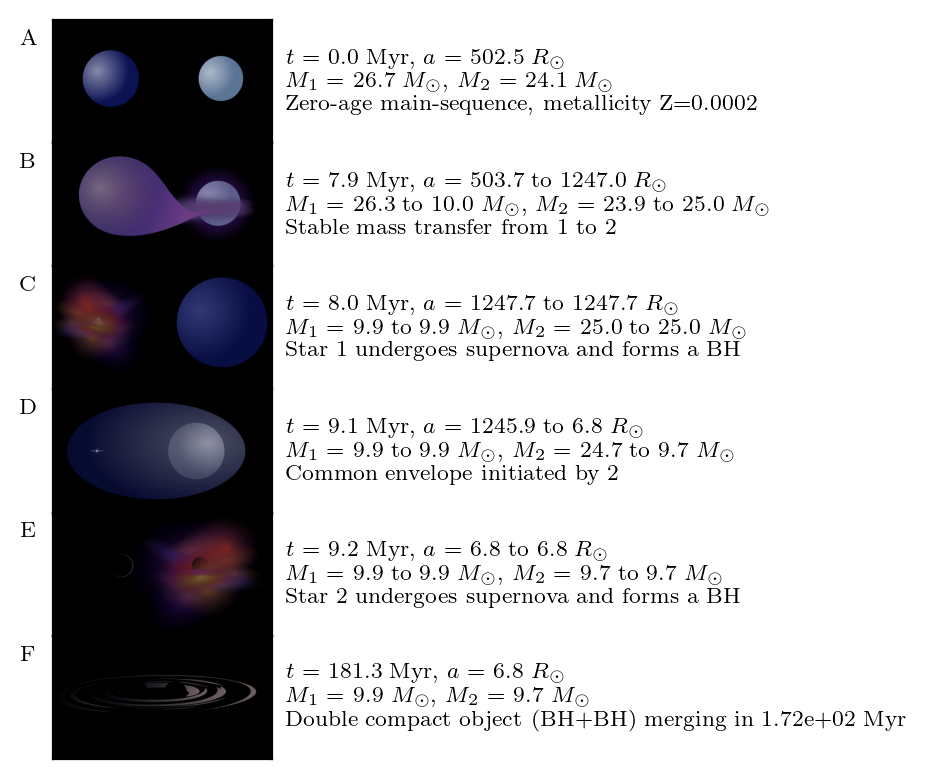

In [44]:
RawData = df_detailed_perfect
tf = tempfile.TemporaryFile()
Data = h5.File(tf, 'w')
maskRecordType4 = RawData['Record_Type'] == 4     # Filter first for only end-of-timestep events
for key in RawData.keys():
    Data.create_dataset(key, data=RawData[key][maskRecordType4])

### Collect the important events in the detailed evolution
events = det_evo.allEvents(Data).allEvents                 # Calculate the events here, for use in plot sizing parameters
det_evo.printEvolutionaryHistory(events=events)
# det_evo.makeDetailedPlots(Data, events, outdir=None, show=True)
# print("Merges Hubble Time?:", df_dco_perfect['Merges_Hubble_Time'].values.astype(bool))
det_evo.plotVanDenHeuvel(events, outdir=None, use_latex=True)

In [55]:
df_sanity_perfect = pd.read_csv(perfect_DataPath+'/sanity_checks.csv', header=0)
df_sanity_perfect = df_sanity_perfect.rename(columns=lambda x: x.strip())

df_sanity_perfect['SemiMajorAxis_Rsun'] = (df_sanity_perfect['SemiMajorAxis_after'].values * u.AU).to(u.R_sun)
df_sanity_perfect['Period1'] = (2 * np.pi / (df_sanity_perfect['Omega1'].values / u.yr)).to(u.day)
df_sanity_perfect['Period2'] = (2 * np.pi / (df_sanity_perfect['Omega2'].values / u.yr)).to(u.day)
df_sanity_perfect['Period_orb'] = (2 * np.pi / (df_sanity_perfect['Omega'].values / u.yr)).to(u.day)

df_sanity_perfect_short = df_sanity_perfect[columns_to_keep_sanity]

df_sanity_perfect.iloc[np.where(df_sanity_perfect['StellarType_2'] == 7)]

,SEED,Time,Dt,StellarType_1,StellarType_2,J_before,J_after,Jorb_before,Jorb_after,J1_before,J1_after,J2_before,J2_after,Omega_before,Omega,Omega1_before,Omega1,Omega2_before,Omega2,ecc_before,ecc,M1,R1,I1_before,I1_after,M2,R2,I2_before,I2_after,SemiMajorAxis_before,SemiMajorAxis_after,ImK10_1,ImK10_2,ImK12_1,ImK12_2,ImK22_1,ImK22_2,ImK32_1,ImK32_2,ImK10_1_dyn,ImK10_2_dyn,ImK12_1_dyn,ImK12_2_dyn,ImK22_1_dyn,ImK22_2_dyn,ImK32_1_dyn,ImK32_2_dyn,ImK10_1_eq,ImK10_2_eq,ImK12_1_eq,ImK12_2_eq,ImK22_1_eq,ImK22_2_eq,ImK32_1_eq,ImK32_2_eq,M1_core,R1_core,M2_core,R2_core,M1_conv_env,M1_conv_env_max,M2_conv_env,M2_conv_env_max,R1_conv_env_extent,R2_conv_env_extent,tau_conv1,tau_conv2,Lum_1,Lum_2,Temp_1,Temp_2,dadt1,dadt2,dOmegadt1,dOmegadt2,dedt1,dedt2,DaDt_tidal,DeDt_tidal,DOmegaDt_tidal,suggested_dt,dM1_winds,dM2_winds,dM1_MT,dM2_MT,ImK10_Zahn_Equilibrium1,ImK10_Zahn_Equilibrium2,ImK12_Zahn_Equilibrium1,ImK12_Zahn_Equilibrium2,ImK22_Zahn_Equilibrium1,ImK22_Zahn_Equilibrium2,ImK32_Zahn_Equilibrium1,ImK32_Zahn_Equilibrium2,ImK10_Zahn_Dynamical1,ImK10_Zahn_Dynamical2,ImK12_Zahn_Dynamical1,ImK12_Zahn_Dynamical2,ImK22_Zahn_Dynamical1,ImK22_Zahn_Dynamical2,ImK32_Zahn_Dynamical1,ImK32_Zahn_Dynamical2,DSemiMajorAxis1Dt_tidal_Zahn,DSemiMajorAxis2Dt_tidal_Zahn,DEccentricity1Dt_tidal_Zahn,DEccentricity2Dt_tidal_Zahn,DOmega1Dt_tidal_Zahn,DOmega2Dt_tidal_Zahn,SemiMajorAxis_Rsun,Period1,Period2,Period_orb
8637,1919508,9.11085,0.000041,14,7,24.3699,24.3699,24.3698,24.3698,0.000076,0.000076,0.000019,0.000022,4922.91,4922.91,493759000.0,493759000.0,1.04242,1.16566,0.0,0.0,9.94871,0.000042,1.531390e-13,1.531390e-13,9.69801,0.943757,0.000019,0.000019,0.031749,0.031749,0.0,4.132050e-18,0.0,4.127380e-18,0.0,2.622210e-17,0.0,7.732590e-17,0.0,4.132050e-18,0.0,4.127380e-18,0.0,2.622210e-17,0.0,7.732590e-17,0,0,0,0,0,0,0,0,9.94871,0.000042,6.44233,0.030493,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.000000e-10,195342.0,0.486893,21.6406,0.0,-6.367030e-19,0.0,1.308060e-11,0.0,-0.0,4.986530e+08,inf,3.763530e+06,3.763530e+06,0.0,0.000000e+00,0.0,-15.0199,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,3.919280e-27,-9.449690e-10,-5.404190e-13,9.439020e-10,-5.404120e-13,5.996790e-09,-5.404050e-13,1.768390e-08,2.224270e-36,-1.456090e-10,0.0,-0.0,-5.574280e-21,0.002991,6.827142,0.000005,1968.784580,0.466174
8638,1919508,9.11089,0.000904,14,7,24.3698,24.3698,24.3697,24.3697,0.000076,0.000076,0.000022,0.000072,4922.89,4922.92,493759000.0,493759000.0,1.16575,3.86824,0.0,0.0,9.94871,0.000042,1.531390e-13,1.531390e-13,9.69797,0.943712,0.000019,0.000019,0.031749,0.031749,0.0,4.059650e-18,0.0,4.054530e-18,0.0,2.576090e-17,0.0,7.596780e-17,0.0,4.059650e-18,0.0,4.054530e-18,0.0,2.576090e-17,0.0,7.596780e-17,0,0,0,0,0,0,0,0,9.94871,0.000042,6.44257,0.030433,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.000000e-10,195345.0,0.486893,21.6412,0.0,-6.253510e-19,0.0,1.284860e-11,0.0,-0.0,5.077070e+08,inf,3.831460e+06,3.831460e+06,0.0,-4.217440e-05,0.0,0.0000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,3.919240e-27,-9.447700e-10,-5.404190e-13,9.435770e-10,-5.404120e-13,5.995130e-09,-5.404050e-13,1.767940e-08,2.224230e-36,-1.455330e-10,0.0,-0.0,-5.574170e-21,0.002990,6.827120,0.000005,593.275865,0.466173
8639,1919508,9.11180,0.000900,14,7,24.3698,24.3698,24.3696,24.3696,0.000076,0.000076,0.000072,0.000122,4922.90,4922.93,493759000.0,493759000.0,3.87595,6.54312,0.0,0.0,9.94871,0.000042,1.531390e-13,1.531390e-13,9.69792,0.942761,0.000019,0.000019,0.031749,0.031749,0.0,2.731600e-18,0.0,2.720150e-18,0.0,1.730820e-17,0.0,5.106610e-17,0.0,2.731600e-18,0.0,2.720150e-18,0.0,1.730820e-17,0.0,5.106610e-17,0,0,0,0,0,0,0,0,9.94871,0.000042,6.44861,0.029110,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.000000e-10,195450.0,0.486893,21.6550,0.0,-4.180540e-19,0.0,8.606770e-12,0.0,-0.0,7.594580e+08,inf,5.719800e+06,5.719800e+06,0.0,-4.200920e-05,0.0,0.0000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,3.919260e-27,-9.409680e-10,-5.404190e-13,9.370220e-10,-5.404120e-13,5.962240e-09,-5.404050e-13,1.759100e-08,2.224250e-36,-1.440090e-10,0.0,-0.0,-5.574180e-21,0.002965,6.827120,0.0

In [41]:
st_change_idx = np.where((df_sanity_perfect_short['StellarType_1'] != df_sanity_perfect_short['StellarType_1'].shift()) | (df_sanity_perfect_short['StellarType_2'] != df_sanity_perfect_short['StellarType_2'].shift()))[0]
st_changes_with_buffer = np.concatenate([st_change_idx, st_change_idx-1])
st_changes_with_buffer.sort()
df_sanity_perfect_short.iloc[st_changes_with_buffer][1:]

,Time,M1,M2,R1,R2,SemiMajorAxis_Rsun,ecc,StellarType_1,StellarType_2,Period1,Period2,Period_orb,J1_after,J2_after,Jorb_after,dM1_MT,dM2_MT,ImK22_1,ImK22_2,ImK22_1_dyn,ImK22_2_dyn,ImK22_1_eq,ImK22_2_eq,ImK22_Zahn_Equilibrium1,ImK22_Zahn_Equilibrium2,ImK22_Zahn_Dynamical1,ImK22_Zahn_Dynamical2
0,0.00000,26.70760,24.13840,4.800230,4.521210,502.452736,3.941130e-02,1,1,1.523638e+16,1.992182e+16,182.957981,2.004660e-16,1.229290e-16,867.6690,0.0000,0.00000,5.169080e-11,3.846470e-11,5.169080e-11,3.846470e-11,0,0,0.000000e+00,0.000000e+00,2.237830e-12,1.512230e-12
1288,7.30215,26.37570,23.93700,11.701300,10.037000,507.779083,3.941130e-02,1,1,1.489027e+09,1.340381e+10,186.856441,1.203730e-08,8.929140e-10,858.7440,0.0000,0.00000,5.360000e-17,2.817450e-16,5.360000e-17,2.817450e-16,0,0,0.000000e+00,0.000000e+00,7.330030e-11,3.428490e-11
1289,7.30215,26.37560,23.93700,11.495300,10.037000,507.781233,3.941130e-02,2,1,1.006461e+09,1.338841e+10,186.857962,1.204030e-08,8.939400e-10,858.7420,0.0000,0.00000,5.857600e-17,2.817400e-16,5.857600e-17,2.817400e-16,0,0,inf,0.000000e+00,6.827350e-11,3.428440e-11
2368,7.31306,26.37480,23.93640,35.714000,10.071500,507.794135,3.941130e-02,2,1,6.149059e+08,1.318829e+10,186.867091,1.877980e-07,9.137390e-10,858.7190,0.0000,0.00000,2.200730e-19,2.715760e-16,2.200730e-19,2.715760e-16,0,0,7.457440e-74,0.000000e+00,6.359750e-09,3.475250e-11
2369,7.31306,26.37470,23.93640,35.712200,10.071500,507.796285,3.941130e-02,4,1,2.764484e+08,1.314930e+10,186.868613,4.176740e-07,9.164410e-10,858.7150,0.0000,0.00000,2.201240e-19,2.715670e-16,2.201240e-19,2.715670e-16,0,0,7.416580e-74,0.000000e+00,6.358250e-09,3.475120e-11
4112,7.87886,26.30500,23.90590,188.044000,12.502900,503.652616,3.566660e-02,4,1,6.775671e+02,4.556016e+09,184.771298,4.234800e+00,4.071040e-09,852.8280,0.0000,0.00000,1.272780e-22,3.243360e-17,1.272780e-22,3.243360e-17,0,0,5.133630e-23,0.000000e+00,2.152710e-06,8.488470e-11
4113,7.87892,9.95634,25.02020,1.022880,11.192000,1246.971471,0.000000e+00,7,1,6.782319e+02,1.946756e+00,862.445671,7.623180e-05,7.990160e+00,637.3220,-16.3486,1.11437,-1.728270e-20,-2.703480e-11,-1.728270e-20,-2.703480e-11,0,0,0.000000e+00,0.000000e+00,-5.167130e-19,-1.087720e-05
4205,8.00120,9.95051,25.01220,0.933841,11.749700,1247.532705,0.000000e+00,7,1,5.671712e+02,2.149519e+00,863.198264,7.593470e-05,7.973070e+00,637.0140,0.0000,0.00000,0.000000e+00,-1.276400e-11,0.000000e+00,-1.276400e-11,0,0,0.000000e+00,0.000000e+00,-2.042260e-18,-1.013380e-05
4206,8.00120,9.95041,25.01210,0.933839,11.749600,1247.543456,0.000000e+00,8,1,1.789464e+02,2.149579e+00,863.211252,7.591720e-05,7.972770e+00,637.0090,0.0000,0.00000,0.000000e+00,-1.276300e-11,0.000000e+00,-1.276300e-11,0,0,0.000000e+00,0.000000e+00,-4.134750e-16,-1.013290e-05
4332,8.02911,9.94871,25.01040,1.067030,11.887900,1247.678927,0.000000e+00,8,1,1.949799e+02,2.201312e+00,863.396363,7.561610e-05,7.969160e+00,636.9220,0.0000,0.00000,0.000000e+00,-1.067740e-11,0.000000e+00,-1.067740e-11,0,0,0.000000e+00,0.000000e+00,-5.262380e-16,-9.963170e-06


In [43]:
st_labels[7], st_labels[8]

('HeMS', 'HeHG')